In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
sigma_kick = 265 # [ km / s; Hobbs+2005 ]

n = 1_000_000
v = np.random.normal(size=(n, 3))
v *= sigma_kick

In [8]:
def calc_min_fb(v, vesc):
    return 1 - vesc / np.sum(v**2, axis=-1)

(0.0, 1.0)

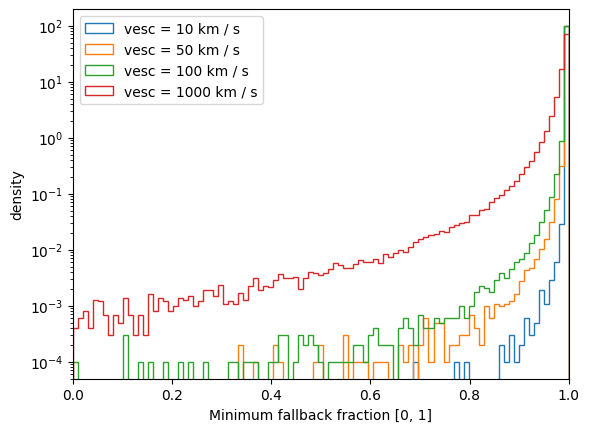

In [9]:
vescs = [10, 50, 100, 1000] # [ km / s ]

bins = np.linspace(0, 1, 100) #np.logspace(-2, 0, 200)

fig, ax = plt.subplots()

for vesc in vescs:
    ax.hist(
        calc_min_fb(v, vesc),
        bins=bins,
        histtype='step',
        density=True,
        label=f'vesc = {vesc} km / s'
    )

ax.set_yscale('log');

ax.set_xlabel('Minimum fallback fraction [0, 1]')
ax.set_ylabel('density')

ax.legend();

ax.set_xlim(0, 1)

Rapid mechanism: $M_\mathrm{proto} = 1.0\,M_\odot$ always

$q_\mathrm{BH} > x + (1 - x) q_\mathrm{proto}$; $q_\mathrm{proto} = 1 / M_\mathrm{presn}$

In [110]:
vesc = 10

sigma_kick = 265 # [ km / s; Hobbs+2005 ]

n = 1_000_000
v = np.random.normal(size=(n, 3))
v *= sigma_kick

x = calc_min_fb(v, vesc)

mbh = 6 # [ Msun ]
mpresn = 7.0 # [ Msun ]

min_mproto = mpresn - mbh / x

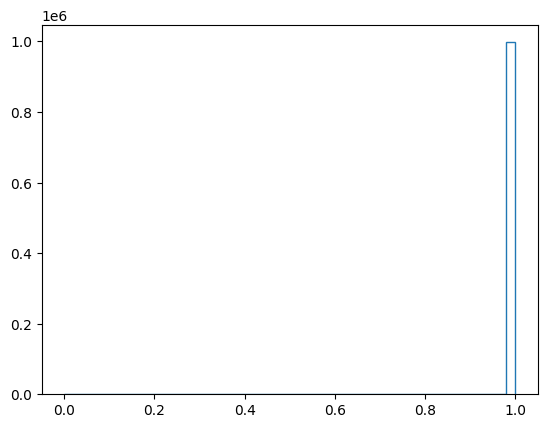

In [111]:
fig, ax = plt.subplots()

masked = np.where(min_mproto < 0, 0, min_mproto)
ax.hist(masked, histtype='step', bins=50);

#ax.set_xlim(0, 4)

In [112]:
masked

array([0.9988683 , 0.97642608, 0.99960408, ..., 0.99986726, 0.99992063,
       0.99944491], shape=(1000000,))

In [69]:
mbh - x * mpresn

array([-0.48638254, -0.48395911, -0.49238951, ..., -0.47207315,
       -0.49810718, -0.49581515], shape=(10000,))

In [71]:
min_mproto.max()

np.float64(3.9216071872730764)